# Animal Classification — ResNet50 + Quantization (TensorFlow)

## 1. Imports

In [1]:
import os, shutil, uuid, time, pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
print("TF version:", tf.__version__)



TF version: 2.21.0


## 2. Kaggle Setup

In [2]:
DATA_DIR = r'C:\Users\Hp\OneDrive\Documents\ML_Internship\Animal\raw-img'

In [ ]:
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')
os.system('kaggle datasets download -d alessiocorrado99/animals10 --unzip -p /content/animals10')

## 3. Rename Folders

In [3]:
DATA_DIR = r'C:\Users\Hp\OneDrive\Documents\ML_Internship\Animal\raw-img'

rename_map = {
    'cane': 'dog', 'cavallo': 'horse', 'elefante': 'elephant',
    'farfalla': 'butterfly', 'gallina': 'chicken', 'gatto': 'cat',
    'mucca': 'cow', 'pecora': 'sheep', 'ragno': 'spider', 'scoiattolo': 'squirrel'
}

for italian, english in rename_map.items():
    old_path = os.path.join(DATA_DIR, italian)
    new_path = os.path.join(DATA_DIR, english)
    if os.path.exists(old_path) and os.path.exists(new_path):
        for file in os.listdir(old_path):
            src = os.path.join(old_path, file)
            dst = os.path.join(new_path, file)
            if os.path.exists(dst):
                name, ext = os.path.splitext(file)
                dst = os.path.join(new_path, f"{name}_{uuid.uuid4().hex[:6]}{ext}")
            shutil.move(src, dst)
        os.rmdir(old_path)
        print(f"Merged: {italian} -> {english}")
    elif os.path.exists(old_path):
        os.rename(old_path, new_path)
        print(f"Renamed: {italian} -> {english}")

print("\nFinal folders:", sorted(os.listdir(DATA_DIR)))


Final folders: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


## 4. Config

In [15]:
SELECTED_CLASSES = ['dog', 'cat', 'horse', 'elephant', 'butterfly']
NUM_CLASSES      = len(SELECTED_CLASSES)
IMG_SIZE      = 64
BATCH_SIZE    = 16
SAMPLES_TRAIN = 500
SAMPLES_VAL   = 100
EPOCHS_P1     = 5
EPOCHS_P2     = 5
AUTOTUNE         = tf.data.AUTOTUNE
SUBSET_DIR = r'C:\Users\Hp\OneDrive\Documents\ML_Internship\Animal\animals_subset'

## 5. Create Subset

In [5]:
if os.path.exists(SUBSET_DIR):
    shutil.rmtree(SUBSET_DIR)
os.makedirs(SUBSET_DIR)

for cls in SELECTED_CLASSES:
    src = os.path.join(DATA_DIR, cls)
    dst = os.path.join(SUBSET_DIR, cls)
    os.makedirs(dst, exist_ok=True)
    all_files = [f for f in os.listdir(src) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selected  = all_files[:SAMPLES_TRAIN + SAMPLES_VAL]
    for f in selected:
        shutil.copy(os.path.join(src, f), os.path.join(dst, f))
    print(f"{cls}: {len(selected)} images copied")

print("\nSubset ready!")

dog: 600 images copied
cat: 600 images copied
horse: 600 images copied
elephant: 600 images copied
butterfly: 600 images copied

Subset ready!


## 6. Data Loaders

In [6]:
train_ds = image_dataset_from_directory(
    SUBSET_DIR,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    SUBSET_DIR,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)
print("Train batches:", len(train_ds))
print("Val batches  :", len(val_ds))

Found 3000 files belonging to 5 classes.
Using 2400 files for training.
Found 3000 files belonging to 5 classes.
Using 600 files for validation.
Classes: ['butterfly', 'cat', 'dog', 'elephant', 'horse']
Train batches: 150
Val batches  : 38


In [7]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(AUTOTUNE)

## 7. Sample Images

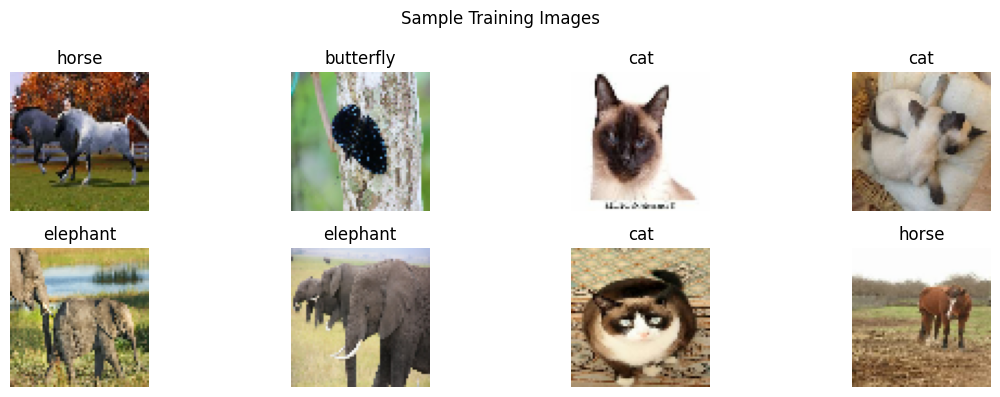

In [8]:
plt.figure(figsize=(12, 4))
for images, labels in train_ds.take(1):
    for i in range(min(8, images.shape[0])):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()

## 8. Build ResNet50 Model

In [17]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = data_augmentation(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512, activation='relu',
                        kernel_initializer='he_normal',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation='relu',
                        kernel_initializer='he_normal',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax',
                        kernel_initializer='glorot_uniform')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,780,677 (94.53 MB)

 Trainable params: 1,187,333 (4.53 MB)

 Non-trainable params: 23,593,344 (90.00 MB)

## 9. Phase 1 — Train Classifier Head

In [18]:
callbacks_p1 = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
    keras.callbacks.ModelCheckpoint('best_model_p1.keras', monitor='val_accuracy', save_best_only=True)
]

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=== PHASE 1: Training classifier head ===")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    callbacks=callbacks_p1
)

=== PHASE 1: Training classifier head ===
Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 40s 215ms/step - accuracy: 0.2792 - loss: 2.2161 - val_accuracy: 0.2033 - val_loss: 1.8308 - learning_rate: 0.0010
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 27s 184ms/step - accuracy: 0.3342 - loss: 1.8867 - val_accuracy: 0.2633 - val_loss: 1.7024 - learning_rate: 0.0010
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 29s 194ms/step - accuracy: 0.3671 - loss: 1.7439 - val_accuracy: 0.3433 - val_loss: 1.6897 - learning_rate: 0.0010
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 27s 177ms/step - accuracy: 0.3629 - loss: 1.6842 - val_accuracy: 0.3267 - val_loss: 1.7254 - learning_rate: 0.0010
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 25s 169ms/step - accuracy: 0.3533 - loss: 1.6736 - val_accuracy: 0.3850 - val_loss: 1.5955 - learning_rate: 0.0010


In [10]:
model = keras.models.load_model('animal_resnet50.keras')

## 10. Phase 2 — Fine-tune Top Layers

In [19]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

callbacks_p2 = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-8),
    keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
]

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=== PHASE 2: Fine-tuning top 40 layers ===")
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    callbacks=callbacks_p2
)

=== PHASE 2: Fine-tuning top 40 layers ===
Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 65s 359ms/step - accuracy: 0.2458 - loss: 1.9434 - val_accuracy: 0.2817 - val_loss: 1.8056 - learning_rate: 1.0000e-05
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 51s 339ms/step - accuracy: 0.2696 - loss: 1.8601 - val_accuracy: 0.2733 - val_loss: 1.7352 - learning_rate: 1.0000e-05
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 51s 339ms/step - accuracy: 0.3038 - loss: 1.8295 - val_accuracy: 0.2800 - val_loss: 1.8227 - learning_rate: 1.0000e-05
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 53s 355ms/step - accuracy: 0.2967 - loss: 1.8044 - val_accuracy: 0.2900 - val_loss: 1.8375 - learning_rate: 1.0000e-05
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 54s 362ms/step - accuracy: 0.2958 - loss: 1.7813 - val_accuracy: 0.3050 - val_loss: 1.8519 - learning_rate: 3.0000e-06


In [21]:
model.save('animal_resnet50.keras')
print("Model saved!")

Model saved!


## 11. Training Curves

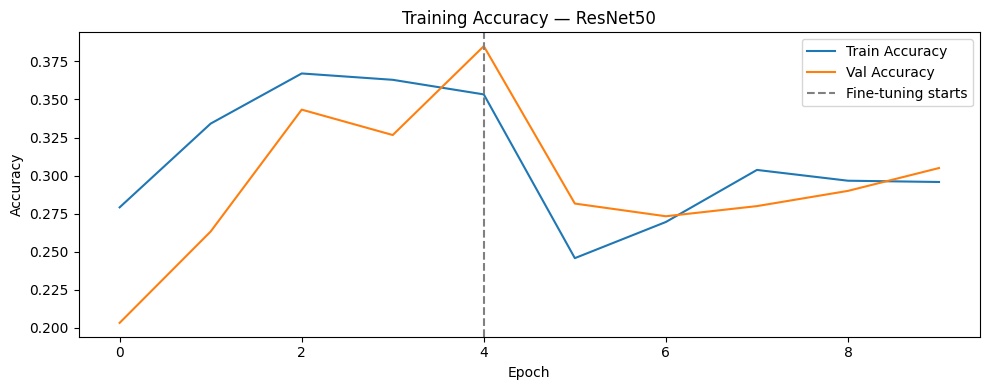

In [20]:
all_acc  = history1.history['accuracy']  + history2.history['accuracy']
all_vacc = history1.history['val_accuracy'] + history2.history['val_accuracy']

plt.figure(figsize=(10, 4))
plt.plot(all_acc,  label='Train Accuracy')
plt.plot(all_vacc, label='Val Accuracy')
plt.axvline(x=len(history1.history['accuracy']) - 1, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training Accuracy — ResNet50')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Evaluate Original Model

In [22]:
model = keras.models.load_model('best_model.keras')

orig_loss, orig_acc = model.evaluate(val_ds)
print(f"Original Model — Loss: {orig_loss:.4f}  Accuracy: {orig_acc*100:.2f}%")

38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 177ms/step - accuracy: 0.3050 - loss: 1.8519
Original Model — Loss: 1.8519  Accuracy: 30.50%


## 13. Save Original Model

In [23]:
model.save('animal_resnet50.keras')
orig_size = os.path.getsize('animal_resnet50.keras') / (1024 * 1024)
print(f"Original Model Size: {orig_size:.2f} MB")

Original Model Size: 225.08 MB


## 14. Post-Training Quantization (TFLite INT8)

In [24]:
def representative_dataset():
    for images, _ in train_ds.take(200):
        for img in images:
            yield [tf.expand_dims(img, 0)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

with open('animal_resnet50_quantized.tflite', 'wb') as f:
    f.write(tflite_model)

quant_size = os.path.getsize('animal_resnet50_quantized.tflite') / (1024 * 1024)
print(f"Quantized Model Size: {quant_size:.2f} MB")
print(f"Size Reduction      : {((orig_size - quant_size) / orig_size) * 100:.1f}%")

INFO:tensorflow:Assets written to: C:\Users\Hp\AppData\Local\Temp\tmpzyp26ggu\assets


INFO:tensorflow:Assets written to: C:\Users\Hp\AppData\Local\Temp\tmpzyp26ggu\assets


Saved artifact at 'C:\Users\Hp\AppData\Local\Temp\tmpzyp26ggu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2301191491984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2301191490832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2301191491024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2301191496784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2301191493328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2301191491792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2301191490640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2301191491600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2300068856464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2300068864720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  230119148

c:\Users\Hp\OneDrive\Documents\ML_Internship\Animal\quantization_env\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantized Model Size: 24.29 MB
Size Reduction      : 89.2%


## 15. Evaluate Quantized Model

In [25]:
interpreter = tf.lite.Interpreter(model_path='animal_resnet50_quantized.tflite', num_threads=4)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def evaluate_tflite(interp, dataset):
    correct = 0
    total   = 0
    start   = time.time()
    for images, labels in dataset:
        for img, label in zip(images.numpy(), labels.numpy()):
            img_input = np.expand_dims(img, axis=0).astype(np.float32)
            interp.set_tensor(input_details[0]['index'], img_input)
            interp.invoke()
            output  = interp.get_tensor(output_details[0]['index'])
            pred    = np.argmax(output)
            correct += int(pred == label)
            total   += 1
    elapsed = time.time() - start
    return (correct / total) * 100, elapsed

quant_acc, quant_time = evaluate_tflite(interpreter, val_ds)
print(f"Quantized — Accuracy: {quant_acc:.2f}%  |  Inference Time: {quant_time:.2f}s")

c:\Users\Hp\OneDrive\Documents\ML_Internship\Animal\quantization_env\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Quantized — Accuracy: 21.17%  |  Inference Time: 4.47s


## 16. Comparison

In [26]:
start = time.time()
model.evaluate(val_ds, verbose=0)
orig_time = time.time() - start

print(f"Original  — Size: {orig_size:.2f} MB  |  Accuracy: {orig_acc*100:.2f}%  |  Time: {orig_time:.2f}s")
print(f"Quantized — Size: {quant_size:.2f} MB  |  Accuracy: {quant_acc:.2f}%  |  Time: {quant_time:.2f}s")

Original  — Size: 225.08 MB  |  Accuracy: 30.50%  |  Time: 6.81s
Quantized — Size: 24.29 MB  |  Accuracy: 21.17%  |  Time: 4.47s


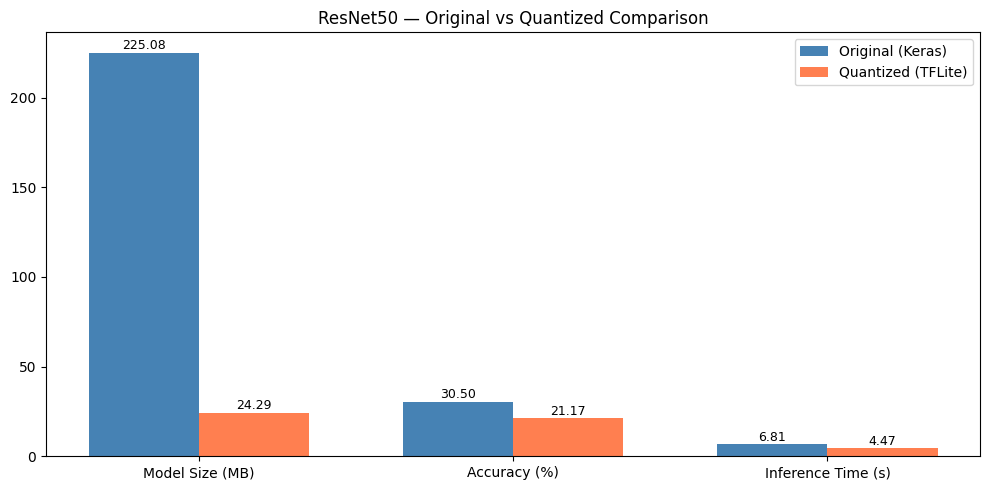

In [27]:
categories = ['Model Size (MB)', 'Accuracy (%)', 'Inference Time (s)']
orig_vals  = [orig_size, orig_acc * 100, orig_time]
quant_vals = [quant_size, quant_acc, quant_time]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, orig_vals,  width, label='Original (Keras)',   color='steelblue')
bars2 = ax.bar(x + width/2, quant_vals, width, label='Quantized (TFLite)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title('ResNet50 — Original vs Quantized Comparison')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 17. Confusion Matrix

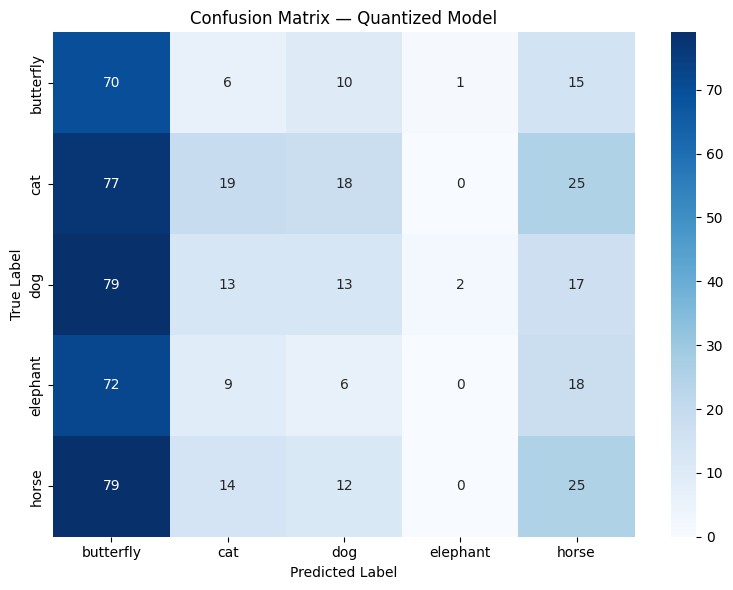

              precision    recall  f1-score   support

   butterfly       0.19      0.69      0.29       102
         cat       0.31      0.14      0.19       139
         dog       0.22      0.10      0.14       124
    elephant       0.00      0.00      0.00       105
       horse       0.25      0.19      0.22       130

    accuracy                           0.21       600
   macro avg       0.19      0.22      0.17       600
weighted avg       0.20      0.21      0.17       600



In [28]:
all_preds  = []
all_labels = []

for images, labels in val_ds:
    for img, label in zip(images.numpy(), labels.numpy()):
        img_input = np.expand_dims(img, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], img_input)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        all_preds.append(np.argmax(output))
        all_labels.append(label)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix — Quantized Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

## 18. Download Models

In [29]:
print("Models saved in your Animal folder!")
print("animal_resnet50.keras")
print("animal_resnet50_quantized.tflite")

Models saved in your Animal folder!
animal_resnet50.keras
animal_resnet50_quantized.tflite
